In [1]:
#dataset = https://www.kaggle.com/datasets/mirichoi0218/insurance/data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [6]:
#downloading dataset:
kagglehub.dataset_download('mirichoi0218/insurance')

100%|██████████| 16.0k/16.0k [00:00<?, ?B/s]

Extracting files...


'C:\\Users\\Lenovo\\.cache\\kagglehub\\datasets\\mirichoi0218\\insurance\\versions\\1'

In [10]:
#importing dataset:
df = pd.read_csv(r'C:\\Users\\Lenovo\\.cache\\kagglehub\\datasets\\mirichoi0218\\insurance\\versions\\1\insurance.csv').dropna()
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [14]:
#defining x and y:
x = df.select_dtypes(include = 'number').drop(columns = ['charges'])
y = df['charges']

In [15]:
#splitting data for training and testing:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

In [16]:
#making ai model:
model = LinearRegression()

In [17]:
#training ai model:
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
#testing ai model based on testing data:
predictions = model.predict(x_test)

# **Evaluating AI Model**

Text(0, 0.5, 'predicted values')

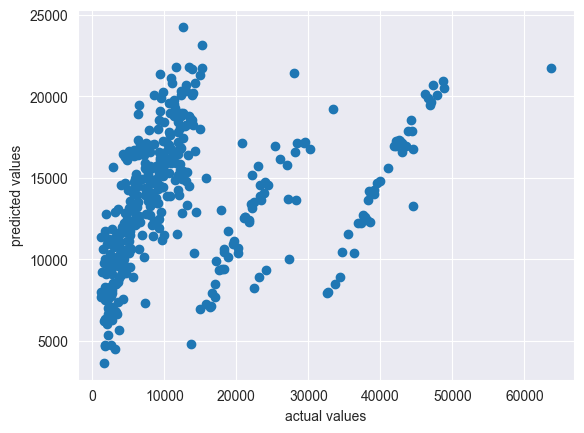

In [21]:
#scatter plot of actual values vs predicted values:
plt.scatter(y_test, predictions)
plt.xlabel('actual values')
plt.ylabel('predicted values')

<Axes: xlabel='charges', ylabel='Count'>

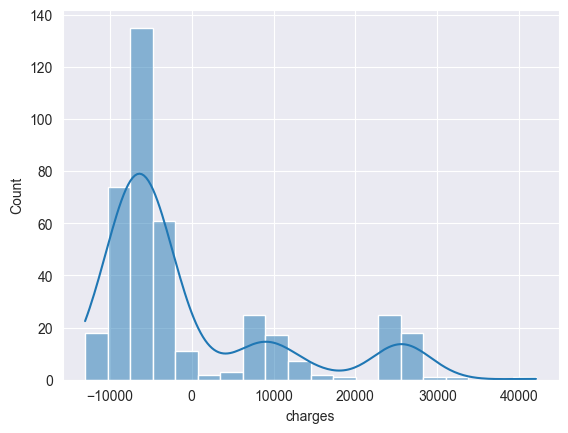

In [22]:
#histogram of residuals:
residuals = y_test - predictions
sns.histplot(residuals, kde = True)

In [23]:
#mae, rmse:
mae = metrics.mean_absolute_error(y_test, predictions)
rmse = np.sqrt(metrics.mean_squared_error(y_test, predictions))
mae_percentage = (mae / y.mean()) * 100
rmse_percentage = (rmse / y.mean()) * 100

print(f'mae percentage = {mae_percentage}')
print(f'rmse percentage = {rmse_percentage}')

#very bad ai model

mae percentage = 68.42019678930126
rmse percentage = 85.05489931795992


# **Conclusion**

In [24]:
pd.DataFrame(data = model.coef_, index = x.columns, columns = ['Coefficient'])

,Coefficient
age,229.034859
bmi,335.553932
children,641.682922
